# Practical Evidence Evaluation, Model comparison, Nested Sampling

## AIC vs BIC

### AIC vs BIC: Definitions and Fundamental Differences

**1. AIC (Akaike Information Criterion)**
* **Definition:** Evaluates the quality of a statistical model by estimating the amount of "information lost" when that model is used to represent the real-world process.
* **Formula:** AIC = 2k - 2ln(L) 
  *(where 'k' is the number of model parameters, and 'L' is the maximum likelihood value)*.

**2. BIC (Bayesian Information Criterion)**
* **Definition:** Based on Bayesian inference, it estimates the posterior probability that a given candidate model is actually the "true" model that generated the data.
* **Formula:** BIC = k*ln(N) - 2ln(L) 
  *(where 'N' is the total number of datapoints or observations)*.

### Logical Differences and When to Use Them

* **Pragmatic vs. Philosophical Approach:** AIC assumes that reality is infinitely complex and that a perfect "true model" does not exist; it merely seeks the most useful approximation. BIC, on the other hand, assumes that the true model is present among the candidates and attempts to isolate it.
* **When to use AIC:** When your primary goal is **pure prediction** (e.g., machine learning, forecasting). You are willing to risk including a few extra, potentially unnecessary parameters to ensure you don't lose predictive power.
* **When to use BIC:** When your goal is **scientific discovery** and inference. You want to identify the fundamental physical or causal factors driving the data, favoring a simpler, more robust, and interpretable model.

### The Crucial Role of N (Number of Datapoints) in BIC

The heart of the difference between the two criteria lies in how they penalize the addition of parameters (k) to prevent overfitting. Both punish complexity, but they do so differently:

* In AIC, the penalty for adding a parameter is fixed (a multiplier of 2).
* In BIC, the penalty for adding a parameter grows logarithmically with the size of the dataset (a multiplier of ln(N)).

**Why is this scaling so fundamental?**
As a dataset becomes massive (e.g., N = 100,000), even a minuscule, random statistical fluctuation can easily produce a mathematically "significant" effect. If the penalty for complexity were fixed (like in AIC), having "big data" would almost always trick the algorithm into accepting useless new parameters, inevitably leading to overfitting. 

By including `ln(N)`, BIC introduces a "dynamic filter." In a gigantic dataset, BIC demands that a new parameter bring a *massive* improvement to the likelihood (L) to justify its existence. This extreme protection against false positives in large samples is exactly what allows BIC to aggressively filter out the noise and isolate the true mathematical structure of the data.

## Evidence computation with MCMC

We've discussed Bayesian parameter estimation algorithms in detail. Crucially, all you get out of an MCMC are samples from the posteriors. There is no information regarding the evidence.


### 1) Savage Dicky Density Ratio

The savage dicky density ratio can be use as to do model **comparison between nested models**. Saying that one model is nested in the other means that one is a special case of the broader one, parametrized with some $\theta$. An example is a general model (signal + noise) and a model with noise only (nested model). 

This trick mathematically evaluate the prior and the posterior of the broader model, **marginalized**, at the value of the $\theta$ estimated with MCMC. Even if the formula is analitically correct, the value it's actually just an estimate since the sampling performed with MCMC is limited.

$$\frac{\mathcal{Z}_2}{\mathcal{Z}_1} = \frac{p(A=0)}{p(A=0|d,n)}$$

### 2) Product-space sampling (or "hypermodels")

Run MCMC with an extra parameter to produce a sampler that jumpes between models deoending on the value of the extra parameter

* Run a big MCMC chain that includes all parameters of all models, in addition to a model indexing parameter, .
* Define distinct ranges for this parameter, such that in certain sampling ranges it will trigger one of the model likelihoods to be used, e.g. if  use the likelihood for model .
* After sampling sufficiently long, the MCMC chain will spend different amounts of time in differnt regions of  in proportion to the Bayesian odds ratio. Hence, the ratio of samples in model sub-ranges gives the Bayesian odds ratio, thus a measure of the more probable model.

## Nested Sampling


### Description

Unlike standard MCMC, where sample density directly represents posterior probability, Nested Sampling algorithmically "peels" the parameter space in concentric shells of **shrinking prior volume**. 

Because the samples are drawn based on volume reduction rather than target probability, each "dead point" (sample) must be assigned a **statistical weight** to accurately reconstruct the true posterior distribution. The weight balances the quality of the fit with the physical size of the parameter space the sample represents:

$$w_i = L_i \times \Delta X_i$$

*   $w_i$: Statistical weight of the sample
*   $L_i$: Likelihood of the sample
*   $\Delta X_i$: Prior Volume represented by the sample

**The Evidence Computation:**
The primary advantage of assigning these weights is that it makes calculating the **Bayesian Evidence** (or Marginal Likelihood, $\mathcal{Z}$) trivial. The total evidence is simply the sum of all the individual sample weights:

$$\mathcal{Z} \approx \sum_{i} w_i = \sum_{i} L_i \Delta X_i$$

**Posterior Sampling:**
In Nested Sampling, computing the posterior and the Evidence are inseparable operations. The normalized posterior probability $P_i$ of each sample is obtained by dividing its raw weight by the total Evidence:

$$P_i = \frac{w_i}{\mathcal{Z}}$$

While MCMC represents probability through the *density* of unweighted points, Nested Sampling represents it through these $P_i$ values. To create standard visualizations (like corner plots), you must **resample** the data: you randomly draw from the physical sample coordinates ($x_i$) using $P_i$ as the probability of selection. This converts the weighted points into a flat, unweighted chain, perfectly equivalent to a standard MCMC output.

### Procedure

* One starts with many points spread throughout the prior volume.
* The points are ranked in terms of their likelihood. Save the point with least likelihood as a sample point with weight $w_i$.

* The lowest ranked point is removed, and a higher likelihood point is randomly added, proposed by a MCMC with a very low rejection rate At each iteration .
* This is repeated, until the cluster of points climbs up the likelihood surface, accumulating Bayesian evidence information along the way.

An example is **Dynesty** which requires in input a log likelihood, a trasformation from the unit volume of the prior to the actual prior and the number of dimension of the problem.

### Comments

* Nested sampling can be **more efficent then MCMC** in producing the sampling, beyond the problem of evidence. It explores much less the region of the posterior which are not intersting reling on the weight tecnique.

* Samples that come out of a nested sampling runs are **weighted**. The results of nested sampling and the samples and their weights together. \
Do not use samples by themselves, to build an histo, use # Resample weighted samples.
samples_equal = dyfunc.resample_equal(samples, weights)

### Dynesty

To follow dynesty algorithm **4 track plots** are made. Key moment when the Evidence value converges.

* The number of live points as a function of prior volume X. The number of live points remains constant until sampling terminates 
* The (normalized) likelihood limit. This increases monotonically as we sample increasingly smaller regions of the prior. 
* The importance weight PDF p(X), roughly divided into regions dominated by the prior volume (dX is large, L(X) is small; yellow), posterior mass (dX and L(X) are comparable; orange), and likelihood density (dX is small, {(X) is large; red). The posterior mass is the most important for posterior estimation, while evidence estimation also depends on the prior volume.
* Bottom: The estimated evidence Z(X) and sigmas bandwidth.

## Transient Universe

### Last Model

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import dynesty 

data = np.load("transient.npy")
time, flux, error = data.T

ndim = 4

def Model(t, b, A, alpha, t0):
    model = np.full_like(t, b, dtype=float)
    mask = t >= t0
    model[mask] = b + A * np.exp(-alpha * (t[mask] - t0))
    return model

#the log-likelihood, not normalized
def loglike(theta, t, flux, error):
    b, A, alpha, t0 = theta
    model = Model(t, b, A, alpha, t0)
    logL = -0.5 * np.sum(((flux - model) / error) ** 2)
    return logL

def PriorTransf(u):
    b = 50 * u[0]
    A = 50 * u[1]
    alpha = np.exp(-5 + 10 *u[2])
    t0 = 100 * u[3]
    array = np.array([b,A,alpha,t0])
    return array

sampler = dynesty.NestedSampler(loglike, PriorTransf, ndim, logl_args = (time,flux,error))
sampler.run_nested()
sresults = sampler.results


0it [00:00, ?it/s]

3847it [00:15, 16.64it/s, bound: 98 | nc: 405 | ncall: 72825 | eff(%):  5.283 | loglstar:   -inf < -86.536 <    inf | logz: -93.223 +/-  0.106 | dlogz: 35.024 >  0.509]   /opt/anaconda3/lib/python3.12/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or di

Bayesian evidence 3.672802125607851e-28
68% parameter credible regions are:
 [[10.170076343232742, 10.424301899801804], [4.214158229621808, 7.4049301227642506], [0.09762576823564105, 0.1536998335492241], [47.44707149464104, 50.95487606201635]]

Mean and covariance of parameters are: [10.29640166  5.75161036  0.12545378 49.15017201]
[[ 1.52866576e-02  1.50191106e-02  1.42009706e-03 -3.00769328e-03]
 [ 1.50191106e-02  2.76332920e+00  2.82800336e-02 -1.64546392e+00]
 [ 1.42009706e-03  2.82800336e-02  8.22763138e-04 -2.02917485e-03]
 [-3.00769328e-03 -1.64546392e+00 -2.02917485e-03  2.22891830e+00]]


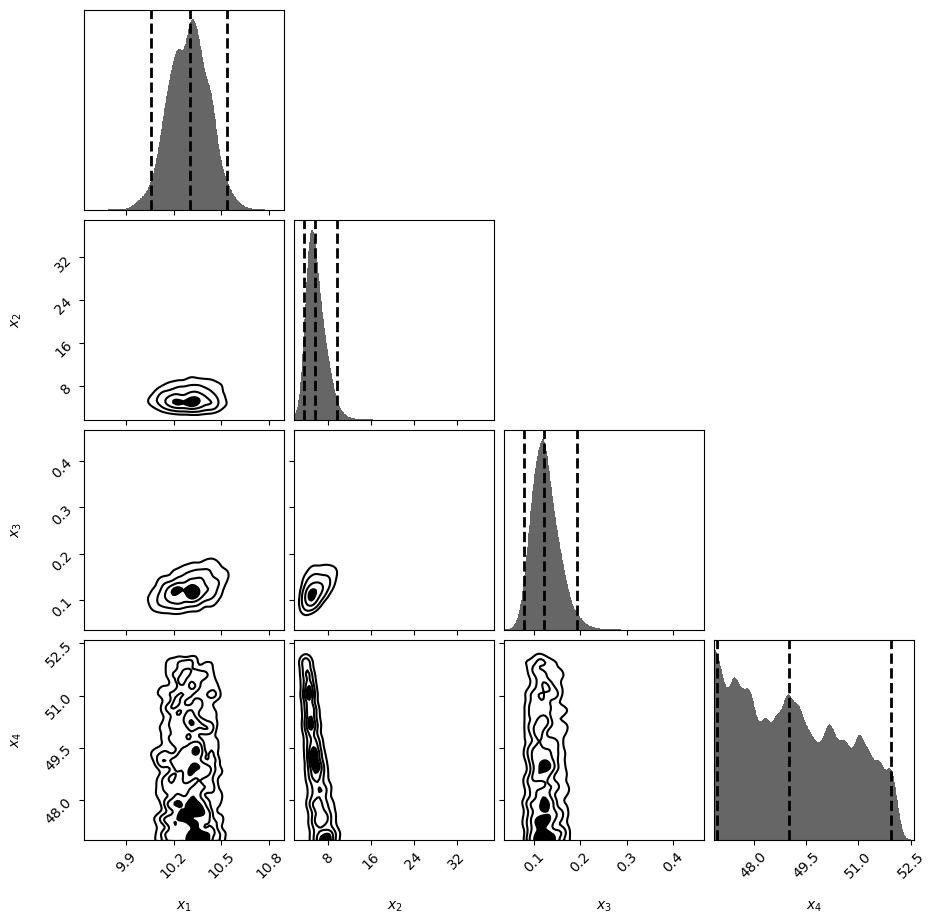

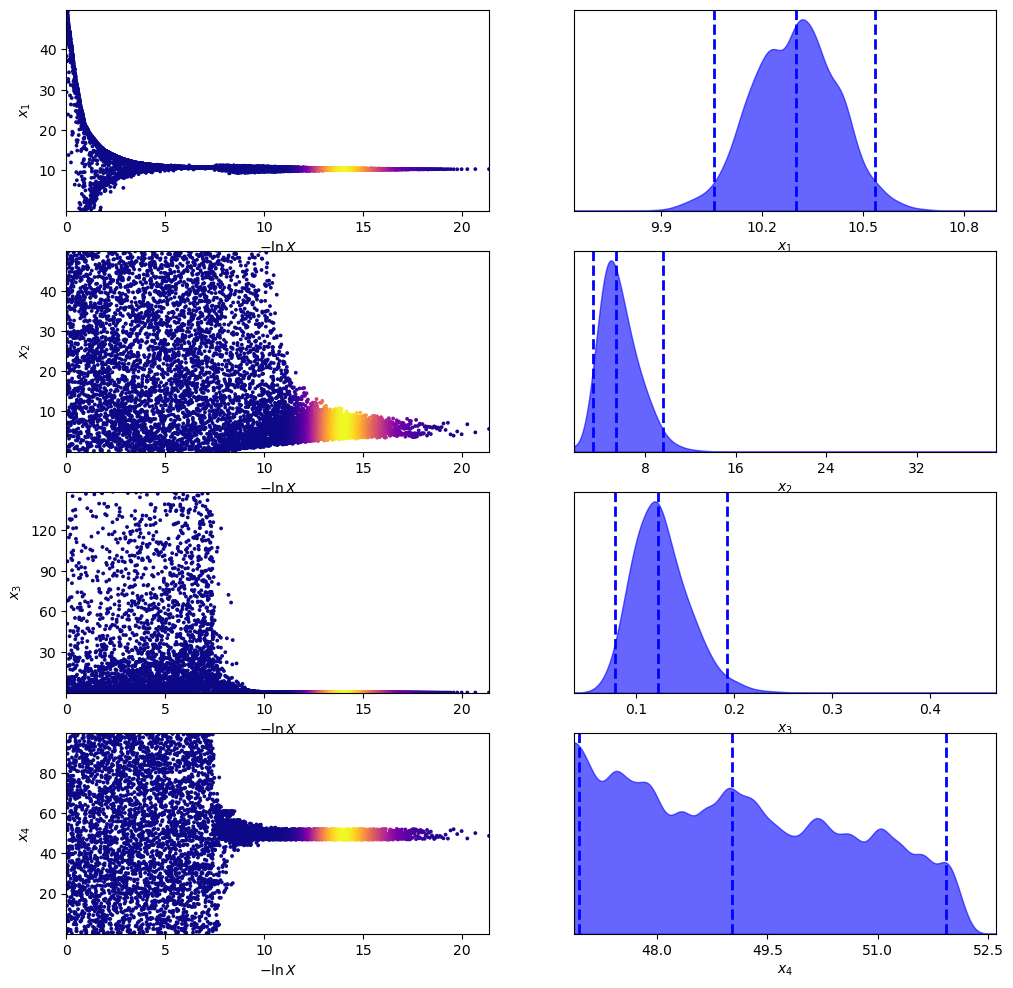

In [21]:
from dynesty import plotting as dyplot
from dynesty import utils as dyfunc
cfig, caxes = dyplot.cornerplot(sresults)
tfig, taxes = dyplot.traceplot(sresults)

# Extract sampling results.
samples = sresults.samples  # samples
weights = np.exp(sresults.logwt - sresults.logz[-1])  # normalized weights

evidence = sresults.logz[-1] #evidence
print("Bayesian evidence", np.exp(evidence))

# Compute 10%-90% quantiles.
quantiles = [dyfunc.quantile(samps, [0.16, 0.84], weights=weights)
             for samps in samples.T]
print('68% parameter credible regions are:\n ' + str(quantiles) + '\n')

# Compute weighted mean and covariance.
mean, cov = dyfunc.mean_and_cov(samples, weights)
print('Mean and covariance of parameters are: ' + str(mean) + '\n' + str(cov))


Corner plots appaiono molto simili a quelli dell'esercizio precedente costruiti con emcee. \
Trace plot si assottigliano come previsto per tutti i parametri.

### Gaussian Model

<function PriorTransf at 0x3163a3c40>


151725it [01:50, 1374.71it/s, +10000 | bound: 37 | nc: 1 | ncall: 3149380 | eff(%):  5.151 | loglstar:   -inf < -48.779 <    inf | logz: -67.191 +/-  0.095 | dlogz:  0.003 > 10.009]


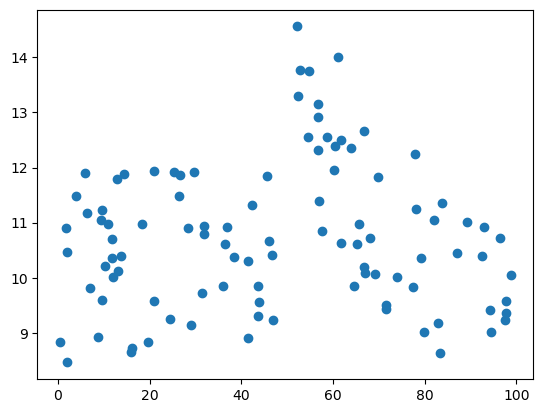

In [15]:
from numpy import array
def GaussianModel(t, b, A, sigma, t0):
    return b + A * np.exp(-((t - t0)**2) / (2 * sigma**2))

plt.scatter(time, flux)
#b tra 10 e 12
#A tra 0 e 6
#t0 tra 0 e 100
#sigma tra 0 e 30

def PriorTransf(u):
    b = u[0] * 50
    A = 50 * u[1]
    t0 = 100 * u[2]
    sigma = 50 * u[3]
    array = np.array([b,A,t0,sigma])
    return array

print(PriorTransf)
ndim = 4

sampler_gauss = dynesty.NestedSampler(loglike, PriorTransf, ndim, logl_args = (time,flux,error), nlive=10000, sample='rwalk')
sampler_gauss.run_nested()
sresults = sampler_gauss.results


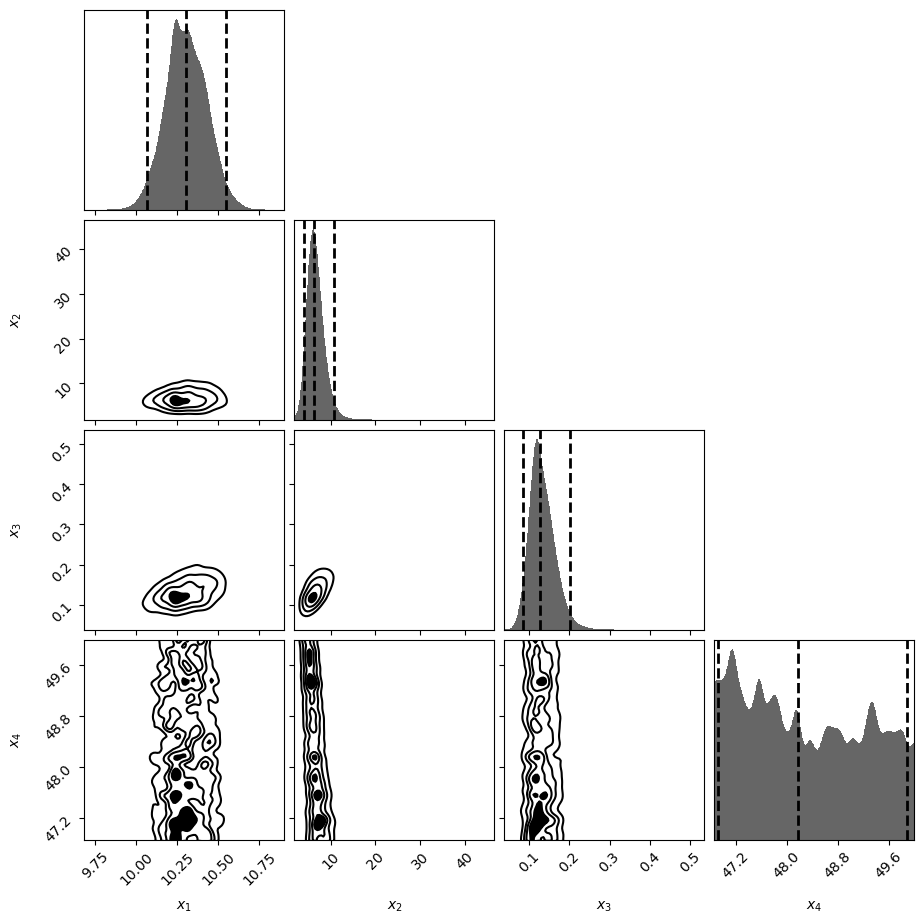

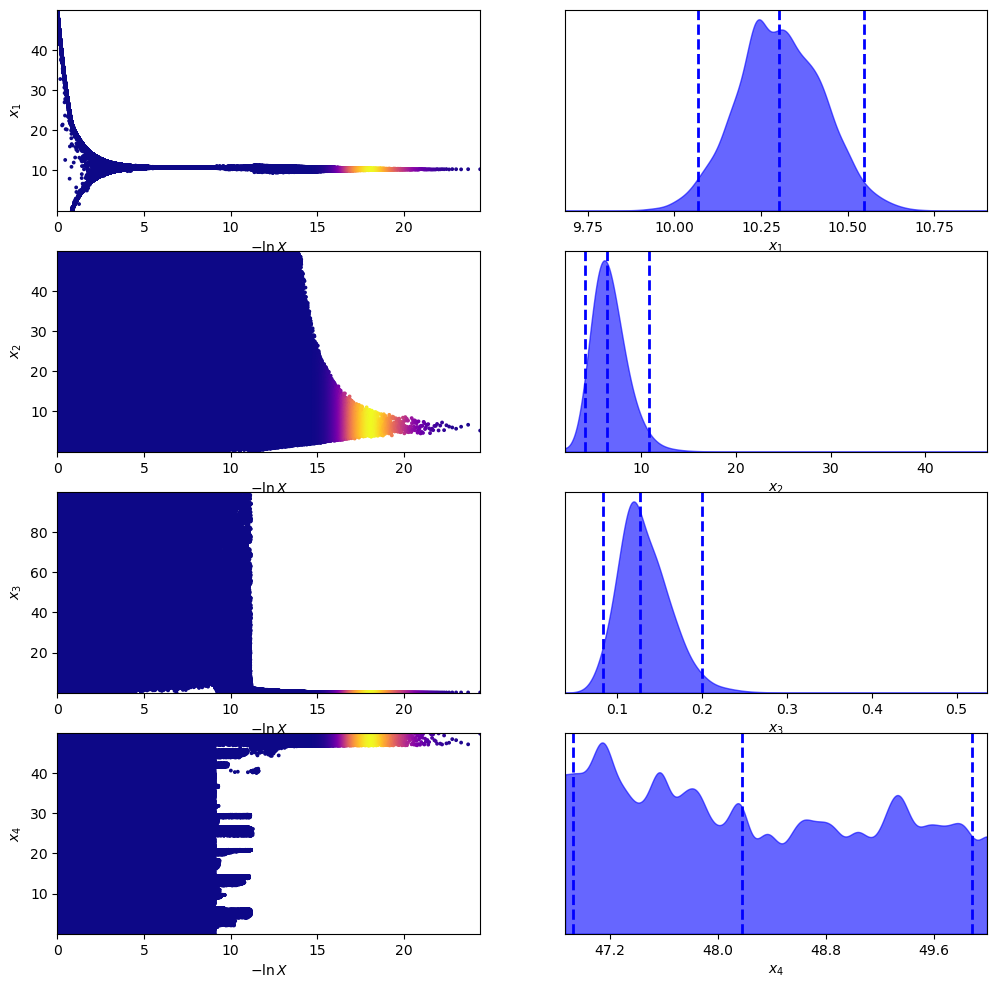

In [ ]:
from dynesty import plotting as dyplot
from dynesty import utils as dyfunc
cfig, caxes = dyplot.cornerplot(sresults)
tfig, taxes = dyplot.traceplot(sresults)

(<Figure size 1600x1600 with 4 Axes>,
 array([<Axes: xlabel='$-\\ln X$', ylabel='Live Points'>,
        <Axes: xlabel='$-\\ln X$', ylabel='Likelihood\n(normalized)'>,
        <Axes: xlabel='$-\\ln X$', ylabel='Importance\nWeight PDF'>,
        <Axes: xlabel='$-\\ln X$', ylabel='Evidence'>], dtype=object))

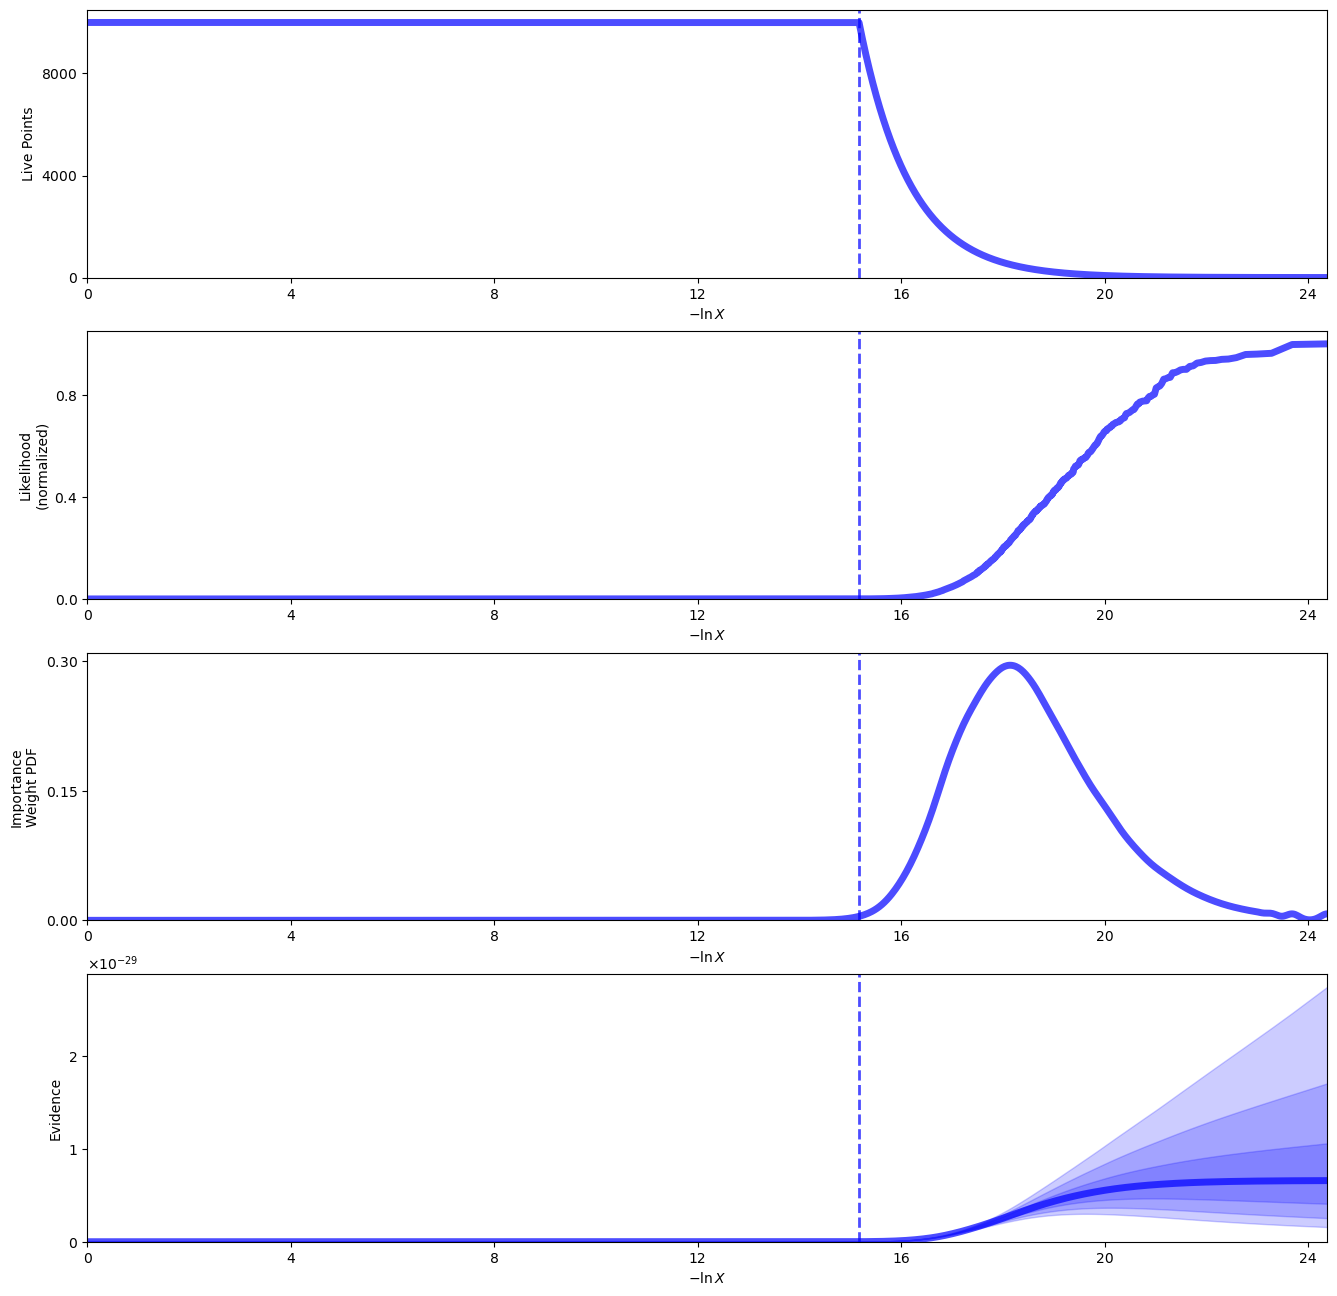

In [18]:
dyplot.runplot(sresults)

corner plots appaiono molto simili a quelli dell'esercizio precedente costruiti con emcee

Attenzione all'errore finale prodotto dal metodo destiny visto che è underestimate, prestare attenzione al fatto che il sample è finito, ogni volta che prendo dati questi camabiano e si crea una varianza, come catturarla? Bootstrap

### **Bayes factor** between gauss and original model

In [22]:
evidence_exp = np.exp(sampler.results['logz'][-1])
evidence_gauss = np.exp(sampler_gauss.results['logz'][-1])

print(f"Evidence for exponential model: {evidence_exp:.3e}")
print(f"Evidence for Gaussian model: {evidence_gauss:.3e}")

print(f"Bayes factor (Exponential / Gaussian): {evidence_exp / evidence_gauss:.3f}")

Evidence for exponential model: 3.673e-28
Evidence for Gaussian model: 6.599e-30
Bayes factor (Exponential / Gaussian): 55.660


vamo raga siui

### Static + Dynamic Dynesty

In [11]:
# "Static" nested sampling.
sampler = dynesty.NestedSampler(loglike, PriorTransf, ndim, logl_args = (time,flux,error))
sampler.run_nested()
sresults = sampler.results

# "Dynamic" nested sampling.
dsampler = dynesty.DynamicNestedSampler(loglike, PriorTransf, ndim, logl_args = (time,flux,error))
dsampler.run_nested()
dresults = dsampler.results

4182it [00:15, 40.95it/s, bound: 72 | nc: 95 | ncall: 57707 | eff(%):  7.247 | loglstar:   -inf < -87.091 <    inf | logz: -92.614 +/-  0.100 | dlogz: 16.228 >  0.509]    /opt/anaconda3/lib/python3.12/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
4187it [00:17, 11.13it/s, bound: 76 | nc: 633 | ncall: 66431 | eff(%):  6.303 | loglstar:   -inf < -87.091 <    inf | logz: -92.613 +/-  0.100 | dlogz: 16.217 >  0.509]/opt/anaconda3/lib/python3.12/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using 

KeyboardInterrupt: 

In [10]:
from dynesty import utils as dyfunc

# Combine results from "Static" and "Dynamic" runs.
results = dyfunc.merge_runs([sresults, dresults])

rfig, raxes = dyplot.runplot(results)
cfig, caxes = dyplot.cornerplot(results)
tfig, taxes = dyplot.traceplot(results)


NameError: name 'dresults' is not defined

In [9]:
# Resample weighted samples.
import corner
samples_equal = dyfunc.resample_equal(results, weights)
corner.corner(samples_equal);

NameError: name 'results' is not defined